In [1]:
%pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn shap

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/8.3 MB 4.2 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.3 MB 4.0 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.3 MB 4.0 MB/s eta 0:00:02
   --------------- ------------------------ 3.1/8.3 MB 3.7 MB/s eta 0:00:02
   -------------------- ------------------- 4.2/8.3 MB 3.8 MB/s eta 0:00:02
   ------------------------- -------------- 5.2/8.3 MB 3.9 MB/s eta 0:00:01
   ---------------------------- ----------- 6.0/8.3 MB 3.9 MB/s eta 0:00:01
   -------------------------------- ------- 6.8/8.3 MB 3.9 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 3.8 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 3.9 MB/s  0:00:02
Using cached xgboost-3.2.0-py3-none

In [1]:
import sys
import pandas as pd
import numpy as np

print("Python executable:")
print(sys.executable)

print("\nPandas version:")
print(pd.__version__)

print("\nNumPy version:")
print(np.__version__)

Python executable:
d:\Fraud Detection system\.venv\Scripts\python.exe

Pandas version:
2.2.3

NumPy version:
2.2.6


In [2]:
# ============================================================
# STEP 2: LOAD AND UNDERSTAND THE DATASET
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. LOAD DATASET
# ------------------------------------------------------------

df = pd.read_csv("../data/creditcard.csv")

print("=" * 60)
print("DATASET LOADED SUCCESSFULLY")
print("=" * 60)

print(f"Rows    : {df.shape[0]:,}")
print(f"Columns : {df.shape[1]}")


# ------------------------------------------------------------
# 2. DISPLAY FIRST 5 ROWS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("FIRST 5 ROWS")
print("=" * 60)

display(df.head())


# ------------------------------------------------------------
# 3. DISPLAY LAST 5 ROWS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("LAST 5 ROWS")
print("=" * 60)

display(df.tail())


# ------------------------------------------------------------
# 4. COLUMN NAMES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("COLUMN NAMES")
print("=" * 60)

for i, column in enumerate(df.columns, start=1):
    print(f"{i:2}. {column}")


# ------------------------------------------------------------
# 5. DATA TYPES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)

print(df.dtypes)


# ------------------------------------------------------------
# 6. BASIC STATISTICS
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)

display(df.describe().T)


# ------------------------------------------------------------
# 7. MISSING VALUES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)

missing_values = df.isnull().sum()

missing_table = pd.DataFrame({
    "Missing Values": missing_values,
    "Percentage": (missing_values / len(df)) * 100
})

display(missing_table)


# ------------------------------------------------------------
# 8. DUPLICATE VALUES
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print(f"Number of duplicate rows: {duplicate_count:,}")


# ------------------------------------------------------------
# 9. TARGET VARIABLE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TARGET VARIABLE: CLASS")
print("=" * 60)

class_counts = df["Class"].value_counts().sort_index()

print(f"Legitimate transactions (0): {class_counts[0]:,}")
print(f"Fraudulent transactions  (1): {class_counts[1]:,}")


# ------------------------------------------------------------
# 10. TARGET PERCENTAGE
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("TARGET PERCENTAGE")
print("=" * 60)

class_percentage = df["Class"].value_counts(normalize=True).sort_index() * 100

print(f"Legitimate: {class_percentage[0]:.4f}%")
print(f"Fraud     : {class_percentage[1]:.4f}%")


# ------------------------------------------------------------
# 11. FRAUD RATIO
# ------------------------------------------------------------

fraud_count = (df["Class"] == 1).sum()
legitimate_count = (df["Class"] == 0).sum()

fraud_ratio = legitimate_count / fraud_count

print("\n" + "=" * 60)
print("FRAUD RATIO")
print("=" * 60)

print(
    f"There are approximately 1 fraud transaction "
    f"for every {fraud_ratio:.0f} legitimate transactions."
)


# ------------------------------------------------------------
# 12. FINAL SUMMARY
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("DATASET SUMMARY")
print("=" * 60)

print(f"Total transactions : {len(df):,}")
print(f"Total features     : {df.shape[1] - 1}")
print(f"Fraud transactions : {fraud_count:,}")
print(f"Legitimate         : {legitimate_count:,}")
print(f"Fraud percentage   : {class_percentage[1]:.4f}%")
print(f"Missing values     : {df.isnull().sum().sum():,}")
print(f"Duplicate rows     : {duplicate_count:,}")

print("\nStep 2 completed successfully!")

DATASET LOADED SUCCESSFULLY
Rows    : 284,807
Columns : 31

FIRST 5 ROWS


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



LAST 5 ROWS


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
284802,172786.0,-11.881118,10.071785,-9.834783,-2.066656,-5.364473,-2.606837,-4.918215,7.305334,1.914428,...,0.213454,0.111864,1.014480,-0.509348,1.436807,0.250034,0.943651,0.823731,0.77,0
284803,172787.0,-0.732789,-0.055080,2.035030,-0.738589,0.868229,1.058415,0.024330,0.294869,0.584800,...,0.214205,0.924384,0.012463,-1.016226,-0.606624,-0.395255,0.068472,-0.053527,24.79,0
284804,172788.0,1.919565,-0.301254,-3.249640,-0.557828,2.630515,3.031260,-0.296827,0.708417,0.432454,...,0.232045,0.578229,-0.037501,0.640134,0.265745,-0.087371,0.004455,-0.026561,67.88,0
284805,172788.0,-0.240440,0.530483,0.702510,0.689799,-0.377961,0.623708,-0.686180,0.679145,0.392087,...,0.265245,0.800049,-0.163298,0.123205,-0.569159,0.546668,0.108821,0.104533,10.00,0
284806,172792.0,-0.533413,-0.189733,0.703337,-0.506271,-0.012546,-0.649617,1.577006,-0.414650,0.486180,...,0.261057,0.643078,0.376777,0.008797,-0.473649,-0.818267,-0.002415,0.013649,217.00,0



COLUMN NAMES
 1. Time
 2. V1
 3. V2
 4. V3
 5. V4
 6. V5
 7. V6
 8. V7
 9. V8
10. V9
11. V10
12. V11
13. V12
14. V13
15. V14
16. V15
17. V16
18. V17
19. V18
20. V19
21. V20
22. V21
23. V22
24. V23
25. V24
26. V25
27. V26
28. V27
29. V28
30. Amount
31. Class

DATA TYPES
Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object

STATISTICAL SUMMARY


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,9.481386e+04,47488.145955,0.000000,54201.500000,84692.000000,139320.500000,172792.000000
V1,284807.0,1.168375e-15,1.958696,-56.407510,-0.920373,0.018109,1.315642,2.454930
V2,284807.0,3.416908e-16,1.651309,-72.715728,-0.598550,0.065486,0.803724,22.057729
V3,284807.0,-1.379537e-15,1.516255,-48.325589,-0.890365,0.179846,1.027196,9.382558
V4,284807.0,2.074095e-15,1.415869,-5.683171,-0.848640,-0.019847,0.743341,16.875344
V5,284807.0,9.604066e-16,1.380247,-113.743307,-0.691597,-0.054336,0.611926,34.801666
V6,284807.0,1.487313e-15,1.332271,-26.160506,-0.768296,-0.274187,0.398565,73.301626
V7,284807.0,-5.556467e-16,1.237094,-43.557242,-0.554076,0.040103,0.570436,120.589494
V8,284807.0,1.213481e-16,1.194353,-73.216718,-0.208630,0.022358,0.327346,20.007208
V9,284807.0,-2.406331e-15,1.098632,-13.434066,-0.643098,-0.051429,0.597139,15.594995



MISSING VALUES


,Missing Values,Percentage
Time,0,0.0
V1,0,0.0
V2,0,0.0
V3,0,0.0
V4,0,0.0
V5,0,0.0
V6,0,0.0
V7,0,0.0
V8,0,0.0
V9,0,0.0



DUPLICATE ROWS
Number of duplicate rows: 1,081

TARGET VARIABLE: CLASS
Legitimate transactions (0): 284,315
Fraudulent transactions  (1): 492

TARGET PERCENTAGE
Legitimate: 99.8273%
Fraud     : 0.1727%

FRAUD RATIO
There are approximately 1 fraud transaction for every 578 legitimate transactions.

DATASET SUMMARY
Total transactions : 284,807
Total features     : 30
Fraud transactions : 492
Legitimate         : 284,315
Fraud percentage   : 0.1727%
Missing values     : 0
Duplicate rows     : 1,081

Step 2 completed successfully!


Dataset shape: (284807, 31)

Transaction distribution:
Class
0    284315
1       492
Name: count, dtype: int64


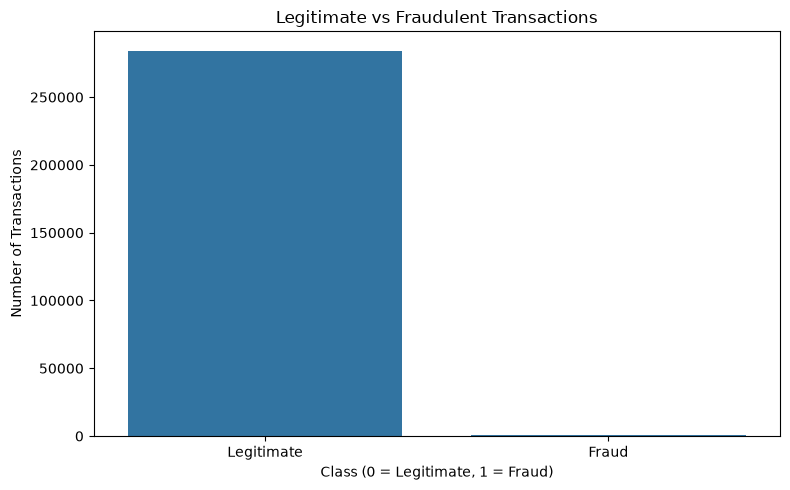


Transaction amount statistics:
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64

Amount statistics by class:


,count,mean,median,std,min,max
Legitimate,284315,88.291022,22.00,250.105092,0.0,25691.16
Fraud,492,122.211321,9.25,256.683288,0.0,2125.87


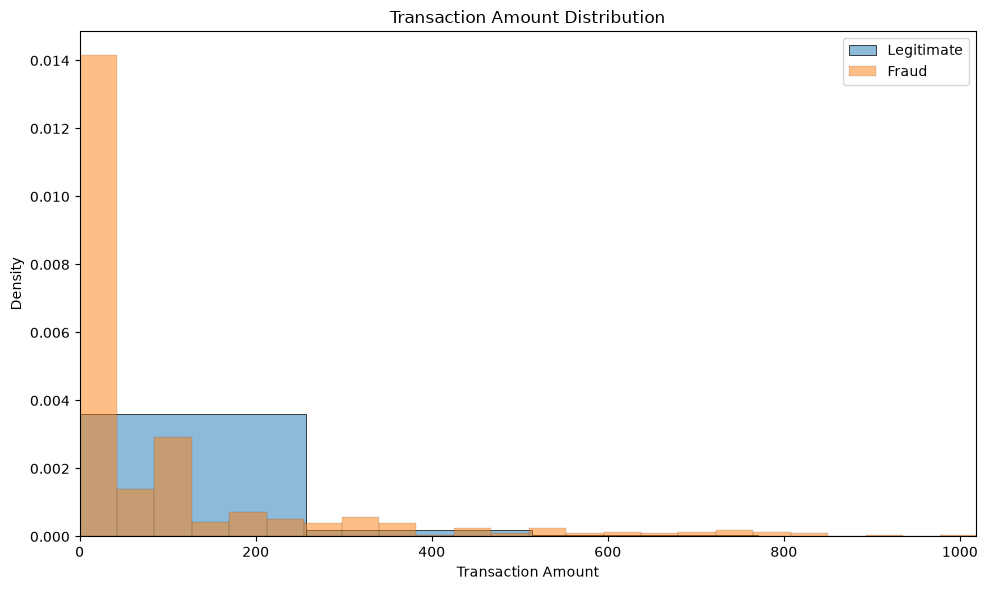

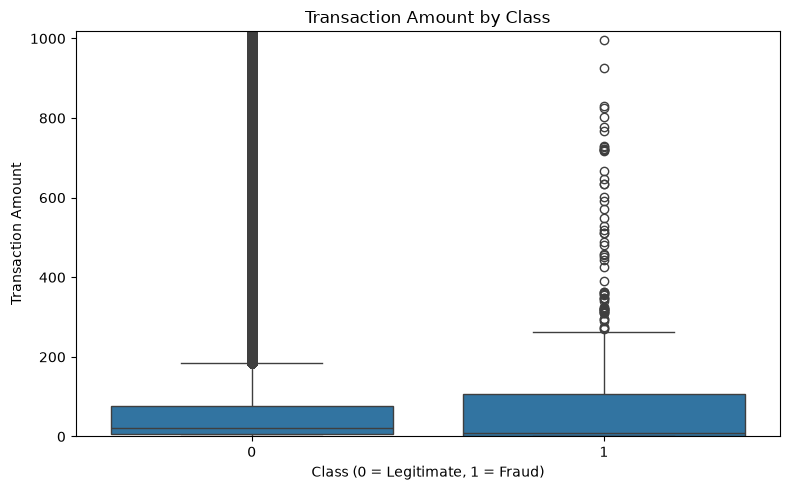

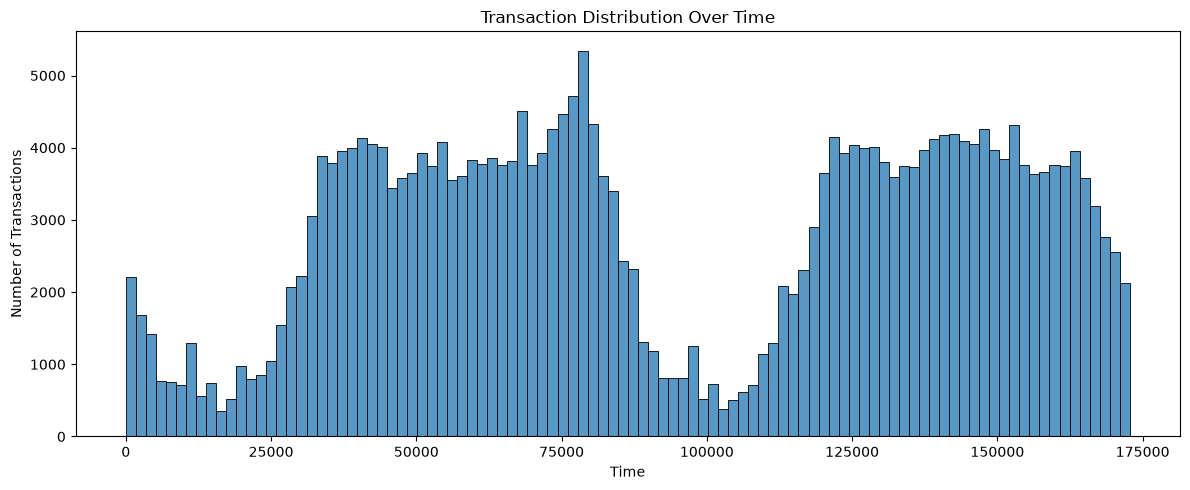

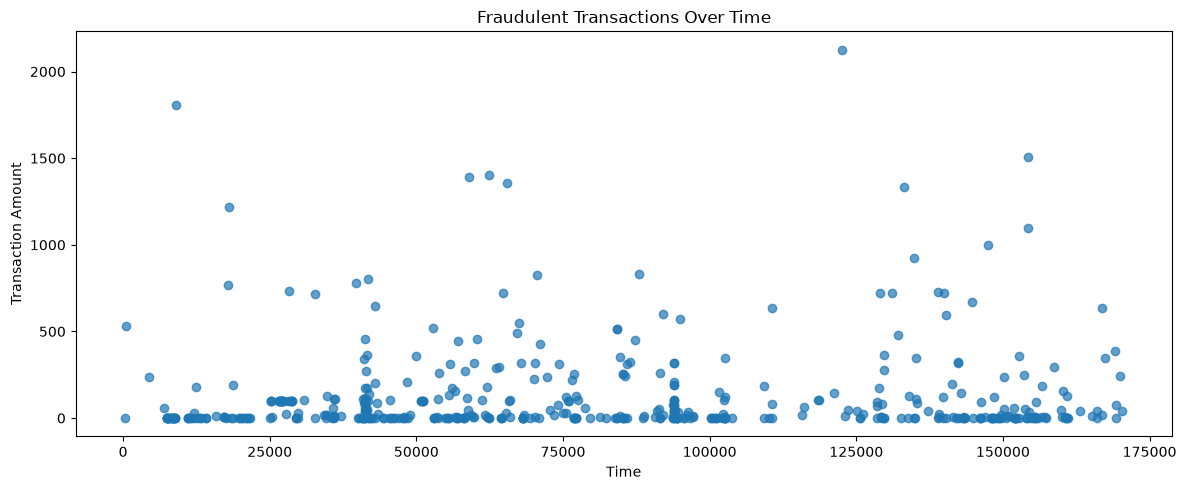


Most positively correlated features:


,Correlation
V11,0.154876
V4,0.133447
V2,0.091289
V21,0.040413
V19,0.034783
V20,0.020090
V8,0.019875
V27,0.017580
V28,0.009536
Amount,0.005632



Most negatively correlated features:


,Correlation
V17,-0.326481
V14,-0.302544
V12,-0.260593
V10,-0.216883
V16,-0.196539
V3,-0.192961
V7,-0.187257
V18,-0.111485
V1,-0.101347
V9,-0.097733



Top features by absolute correlation:


,Absolute Correlation
V17,0.326481
V14,0.302544
V12,0.260593
V10,0.216883
V16,0.196539
V3,0.192961
V7,0.187257
V11,0.154876
V4,0.133447
V18,0.111485


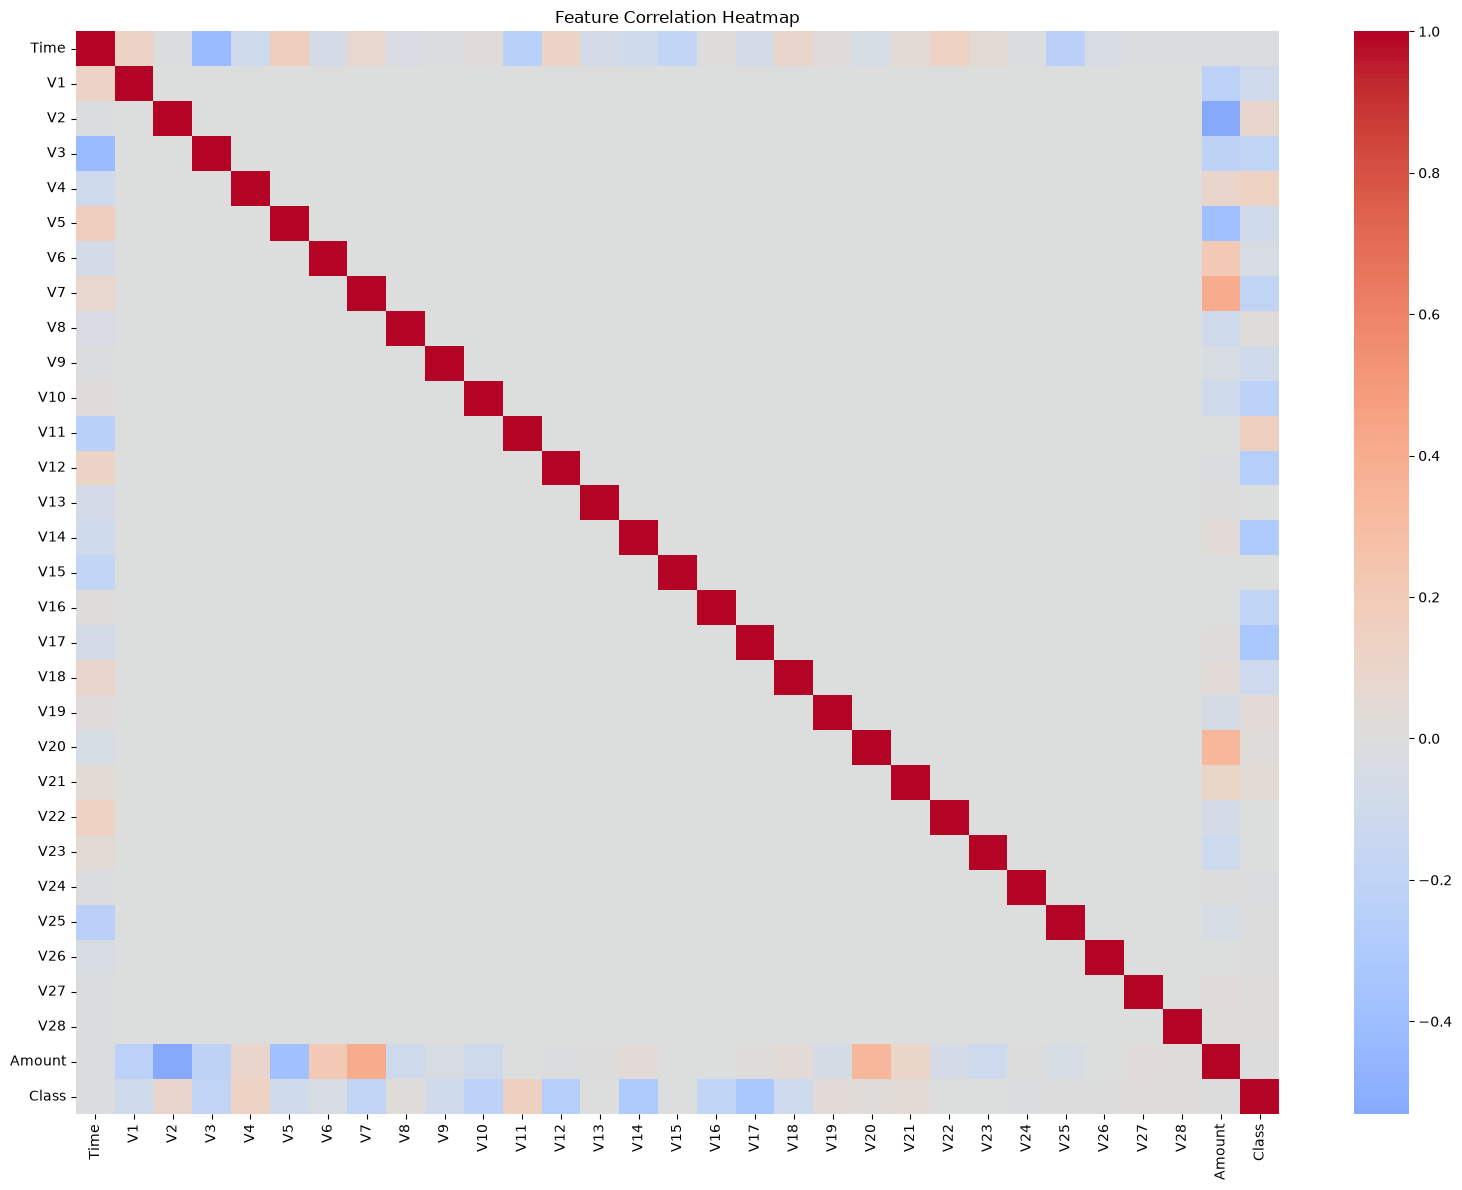


Top correlated features:
['V17', 'V14', 'V12', 'V10', 'V16', 'V3']


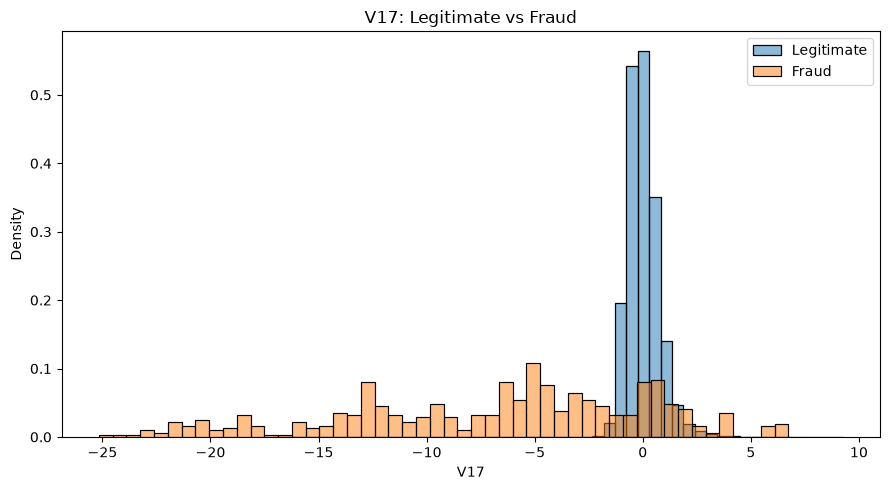

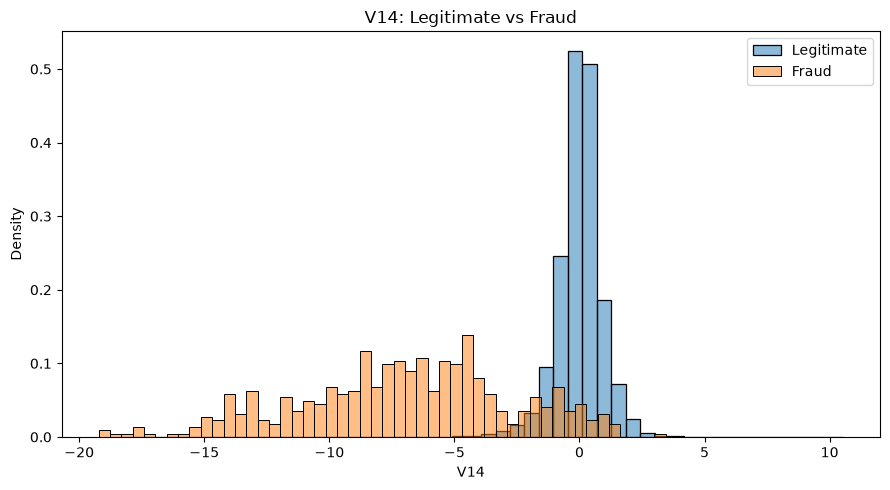

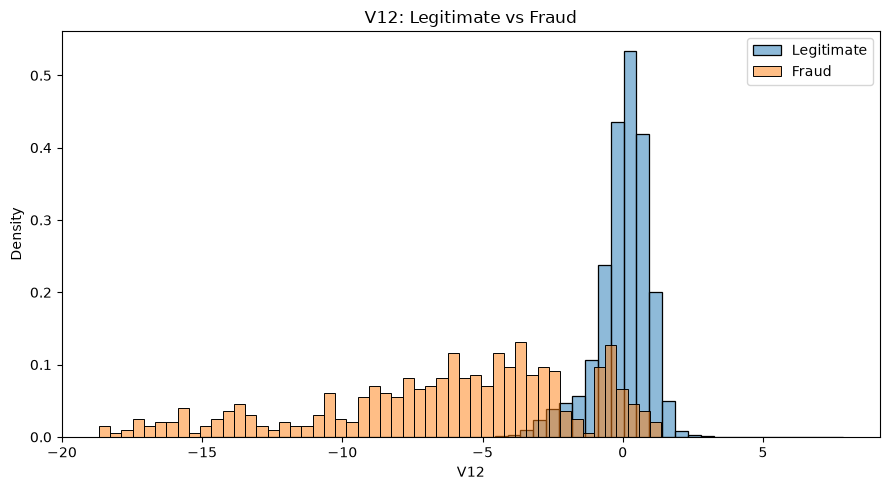

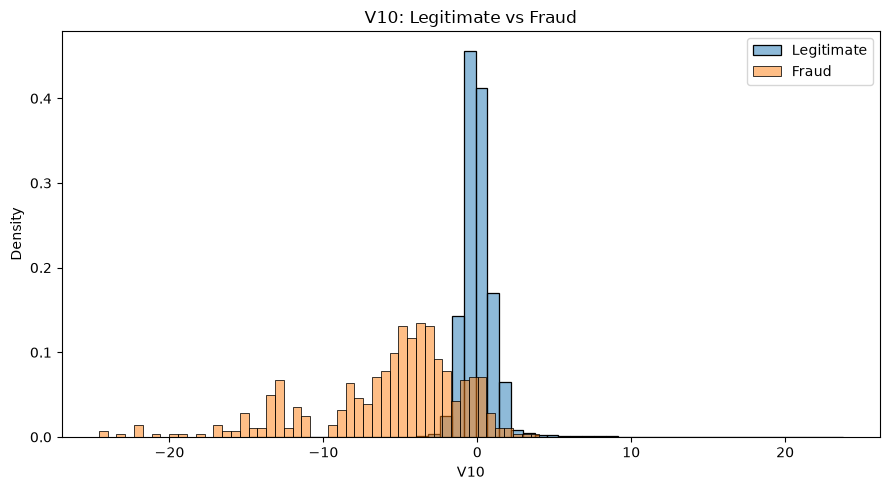

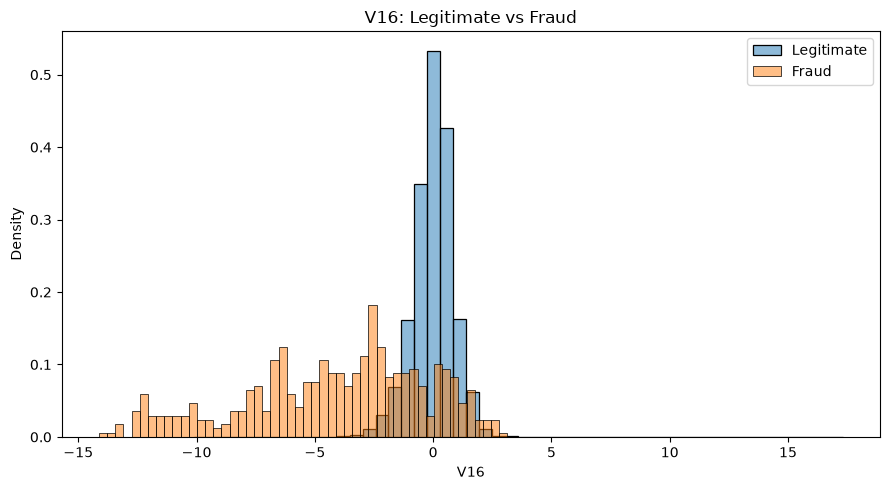

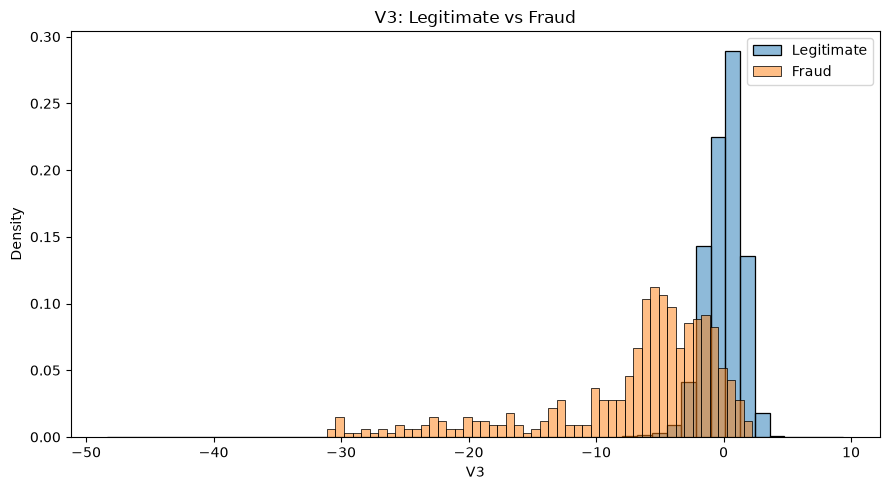


Fraud transaction summary:
Count: 492
Average: 122.21132113821139
Median: 9.25
Minimum: 0.0
Maximum: 2125.87

Legitimate transaction summary:
Count: 284315
Average: 88.29102242231328
Median: 22.0
Minimum: 0.0
Maximum: 25691.16

EDA completed
Total transactions: 284807
Legitimate transactions: 284315
Fraudulent transactions: 492
Fraud percentage: 0.1727%


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Check dataset size
print("Dataset shape:", df.shape)

# Count fraud and legitimate transactions
class_counts = df["Class"].value_counts()

print("\nTransaction distribution:")
print(class_counts)

# Plot transaction classes
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x="Class")

plt.title("Legitimate vs Fraudulent Transactions")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.xticks([0, 1], ["Legitimate", "Fraud"])

plt.tight_layout()
plt.show()

# Check transaction amount statistics
print("\nTransaction amount statistics:")
print(df["Amount"].describe())

# Compare amount statistics by class
amount_statistics = df.groupby("Class")["Amount"].agg(
    ["count", "mean", "median", "std", "min", "max"]
)

amount_statistics.index = ["Legitimate", "Fraud"]

print("\nAmount statistics by class:")
display(amount_statistics)

# Plot amount distributions
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df[df["Class"] == 0],
    x="Amount",
    bins=100,
    stat="density",
    alpha=0.5,
    label="Legitimate"
)

sns.histplot(
    data=df[df["Class"] == 1],
    x="Amount",
    bins=50,
    stat="density",
    alpha=0.5,
    label="Fraud"
)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Density")
plt.legend()

plt.xlim(0, df["Amount"].quantile(0.99))

plt.tight_layout()
plt.show()

# Compare transaction amounts
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Class",
    y="Amount"
)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Legitimate, 1 = Fraud)")
plt.ylabel("Transaction Amount")

plt.ylim(0, df["Amount"].quantile(0.99))

plt.tight_layout()
plt.show()

# Plot transactions over time
plt.figure(figsize=(12, 5))

sns.histplot(
    data=df,
    x="Time",
    bins=100
)

plt.title("Transaction Distribution Over Time")
plt.xlabel("Time")
plt.ylabel("Number of Transactions")

plt.tight_layout()
plt.show()

# Select fraud transactions
fraud_df = df[df["Class"] == 1]

# Plot fraud transactions over time
plt.figure(figsize=(12, 5))

plt.scatter(
    fraud_df["Time"],
    fraud_df["Amount"],
    alpha=0.7
)

plt.title("Fraudulent Transactions Over Time")
plt.xlabel("Time")
plt.ylabel("Transaction Amount")

plt.tight_layout()
plt.show()

# Calculate correlation with the target
correlation = df.corr(numeric_only=True)["Class"].drop("Class")

print("\nMost positively correlated features:")
display(correlation.sort_values(ascending=False).head(10).to_frame("Correlation"))

print("\nMost negatively correlated features:")
display(correlation.sort_values(ascending=True).head(10).to_frame("Correlation"))

# Find features with the strongest correlations
absolute_correlation = correlation.abs().sort_values(ascending=False)

print("\nTop features by absolute correlation:")
display(absolute_correlation.head(15).to_frame("Absolute Correlation"))

# Plot the correlation matrix
plt.figure(figsize=(16, 12))

correlation_matrix = df.corr(numeric_only=True)

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Heatmap")

plt.tight_layout()
plt.show()

# Get the most correlated features
top_features = absolute_correlation.head(6).index.tolist()

print("\nTop correlated features:")
print(top_features)

# Compare important feature distributions
for feature in top_features:
    plt.figure(figsize=(9, 5))

    sns.histplot(
        data=df[df["Class"] == 0],
        x=feature,
        bins=50,
        stat="density",
        alpha=0.5,
        label="Legitimate"
    )

    sns.histplot(
        data=df[df["Class"] == 1],
        x=feature,
        bins=50,
        stat="density",
        alpha=0.5,
        label="Fraud"
    )

    plt.title(f"{feature}: Legitimate vs Fraud")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()

    plt.tight_layout()
    plt.show()

# Analyze fraud transaction amounts
fraud_amount = df.loc[df["Class"] == 1, "Amount"]

print("\nFraud transaction summary:")
print("Count:", len(fraud_amount))
print("Average:", fraud_amount.mean())
print("Median:", fraud_amount.median())
print("Minimum:", fraud_amount.min())
print("Maximum:", fraud_amount.max())

# Analyze legitimate transaction amounts
legitimate_amount = df.loc[df["Class"] == 0, "Amount"]

print("\nLegitimate transaction summary:")
print("Count:", len(legitimate_amount))
print("Average:", legitimate_amount.mean())
print("Median:", legitimate_amount.median())
print("Minimum:", legitimate_amount.min())
print("Maximum:", legitimate_amount.max())

# Show the final EDA summary
print("\nEDA completed")
print("Total transactions:", len(df))
print("Legitimate transactions:", (df["Class"] == 0).sum())
print("Fraudulent transactions:", (df["Class"] == 1).sum())
print("Fraud percentage:", f"{df['Class'].mean() * 100:.4f}%")

In [4]:
from sklearn.model_selection import train_test_split

# Remove duplicate transactions
df = df.drop_duplicates().reset_index(drop=True)

# Separate features and target
X = df.drop("Class", axis=1)
y = df["Class"]

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Show the split sizes
print("Training data:", X_train.shape)
print("Testing data :", X_test.shape)

# Check fraud distribution in the training set
print("\nTraining class distribution:")
print(y_train.value_counts())

# Check fraud distribution in the testing set
print("\nTesting class distribution:")
print(y_test.value_counts())

# Check class percentages
print("\nTraining class percentage:")
print((y_train.value_counts(normalize=True) * 100).sort_index())

print("\nTesting class percentage:")
print((y_test.value_counts(normalize=True) * 100).sort_index())

Training data: (226980, 30)
Testing data : (56746, 30)

Training class distribution:
Class
0    226602
1       378
Name: count, dtype: int64

Testing class distribution:
Class
0    56651
1       95
Name: count, dtype: int64

Training class percentage:
Class
0    99.833466
1     0.166534
Name: proportion, dtype: float64

Testing class percentage:
Class
0    99.832587
1     0.167413
Name: proportion, dtype: float64


In [5]:
from sklearn.preprocessing import StandardScaler

# Create the scaler
scaler = StandardScaler()

# Fit the scaler on training data
X_train_scaled = scaler.fit_transform(X_train)

# Apply the same scaler to test data
X_test_scaled = scaler.transform(X_test)

# Convert the scaled data back to DataFrames
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test.columns,
    index=X_test.index
)

# Check the scaled training data
print("Scaled training data:")
display(X_train_scaled.head())

# Check the mean and standard deviation
print("\nMean of scaled features:")
print(X_train_scaled.mean().round(3).head())

print("\nStandard deviation of scaled features:")
print(X_train_scaled.std().round(3).head())

Scaled training data:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
225399,1.045499,1.147198,-1.042032,-1.428821,-1.817824,0.727198,2.695677,-1.489310,0.735746,-1.152704,...,-0.427196,-0.208573,-0.068205,0.445379,1.130202,-0.420363,-0.331281,0.092782,-0.156193,-0.229434
133746,-0.298690,-0.677911,0.991948,0.394668,-0.025642,-0.301198,-0.728240,0.175615,0.629070,-1.156290,...,-0.089833,-0.332248,-1.307141,0.518036,0.851069,-1.367338,-0.554255,-0.049864,0.153831,-0.331197
185792,0.678397,0.977654,0.016205,-1.386701,0.092688,0.850613,0.458823,-0.019872,0.154370,0.262056,...,-0.277973,0.405040,1.512732,-0.071350,-2.788905,0.202924,0.015479,0.111329,-0.165820,-0.298809
148925,-0.074929,0.927561,0.195261,0.208736,2.739855,0.032003,0.772348,-0.613532,0.199999,0.625478,...,-0.301091,0.190793,0.966846,0.278559,1.160348,-0.407893,-0.021447,-0.049724,-0.119582,-0.289247
18398,-1.376728,0.695218,-0.676118,0.363661,-1.090812,-0.882507,0.209618,-1.002620,0.182243,-1.911610,...,-0.477066,-0.473576,-0.878722,0.404329,-0.568164,-0.123705,-0.913882,0.155776,0.037290,-0.261985



Mean of scaled features:
Time   -0.0
V1      0.0
V2     -0.0
V3      0.0
V4     -0.0
dtype: float64

Standard deviation of scaled features:
Time    1.0
V1      1.0
V2      1.0
V3      1.0
V4      1.0
dtype: float64


In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Create the baseline model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred = logistic_model.predict(X_test_scaled)

# Get fraud probabilities
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

# Display results
print("=" * 50)
print("LOGISTIC REGRESSION RESULTS")
print("=" * 50)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")
print(f"PR-AUC    : {pr_auc:.4f}")

# Show detailed classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=["Legitimate", "Fraud"],
    zero_division=0
))

# Show confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

LOGISTIC REGRESSION RESULTS
Accuracy  : 0.9991
Precision : 0.8462
Recall    : 0.5789
F1 Score  : 0.6875
ROC-AUC   : 0.9560
PR-AUC    : 0.6920

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.85      0.58      0.69        95

    accuracy                           1.00     56746
   macro avg       0.92      0.79      0.84     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56641    10]
 [   40    55]]


In [7]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Create the Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Train the model
random_forest.fit(X_train, y_train)

# Make predictions
rf_pred = random_forest.predict(X_test)

# Get fraud probabilities
rf_prob = random_forest.predict_proba(X_test)[:, 1]

# Calculate evaluation metrics
rf_accuracy = accuracy_score(y_test, rf_pred)
rf_precision = precision_score(y_test, rf_pred, zero_division=0)
rf_recall = recall_score(y_test, rf_pred, zero_division=0)
rf_f1 = f1_score(y_test, rf_pred, zero_division=0)
rf_roc_auc = roc_auc_score(y_test, rf_prob)
rf_pr_auc = average_precision_score(y_test, rf_prob)

# Display results
print("=" * 50)
print("RANDOM FOREST RESULTS")
print("=" * 50)

print(f"Accuracy  : {rf_accuracy:.4f}")
print(f"Precision : {rf_precision:.4f}")
print(f"Recall    : {rf_recall:.4f}")
print(f"F1 Score  : {rf_f1:.4f}")
print(f"ROC-AUC   : {rf_roc_auc:.4f}")
print(f"PR-AUC    : {rf_pr_auc:.4f}")

# Show classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=["Legitimate", "Fraud"],
    zero_division=0
))

# Show confusion matrix
rf_cm = confusion_matrix(y_test, rf_pred)

print("\nConfusion Matrix:")
print(rf_cm)

RANDOM FOREST RESULTS
Accuracy  : 0.9995
Precision : 0.9718
Recall    : 0.7263
F1 Score  : 0.8313
ROC-AUC   : 0.9239
PR-AUC    : 0.7876

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.97      0.73      0.83        95

    accuracy                           1.00     56746
   macro avg       0.99      0.86      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56649     2]
 [   26    69]]


In [8]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report
)

# Create the XGBoost model
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train the model
xgb_model.fit(X_train, y_train)

# Make predictions
xgb_pred = xgb_model.predict(X_test)

# Get fraud probabilities
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

# Calculate metrics
xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred, zero_division=0)
xgb_recall = recall_score(y_test, xgb_pred, zero_division=0)
xgb_f1 = f1_score(y_test, xgb_pred, zero_division=0)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)
xgb_pr_auc = average_precision_score(y_test, xgb_prob)

# Display results
print("=" * 50)
print("XGBOOST RESULTS")
print("=" * 50)

print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1 Score  : {xgb_f1:.4f}")
print(f"ROC-AUC   : {xgb_roc_auc:.4f}")
print(f"PR-AUC    : {xgb_pr_auc:.4f}")

# Show classification report
print("\nClassification Report:")
print(classification_report(
    y_test,
    xgb_pred,
    target_names=["Legitimate", "Fraud"],
    zero_division=0
))

# Show confusion matrix
xgb_cm = confusion_matrix(y_test, xgb_pred)

print("\nConfusion Matrix:")
print(xgb_cm)

XGBOOST RESULTS
Accuracy  : 0.9995
Precision : 0.9595
Recall    : 0.7474
F1 Score  : 0.8402
ROC-AUC   : 0.9803
PR-AUC    : 0.8290

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.96      0.75      0.84        95

    accuracy                           1.00     56746
   macro avg       0.98      0.87      0.92     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56648     3]
 [   24    71]]


In [9]:
# Store the model results
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ],
    "PR-AUC": [
        pr_auc,
        rf_pr_auc,
        xgb_pr_auc
    ]
})

# Round the values for easier reading
results = results.round(4)

# Display the comparison
display(results)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9991,0.8462,0.5789,0.6875,0.9560,0.6920
1,Random Forest,0.9995,0.9718,0.7263,0.8313,0.9239,0.7876
2,XGBoost,0.9995,0.9595,0.7474,0.8402,0.9803,0.8290


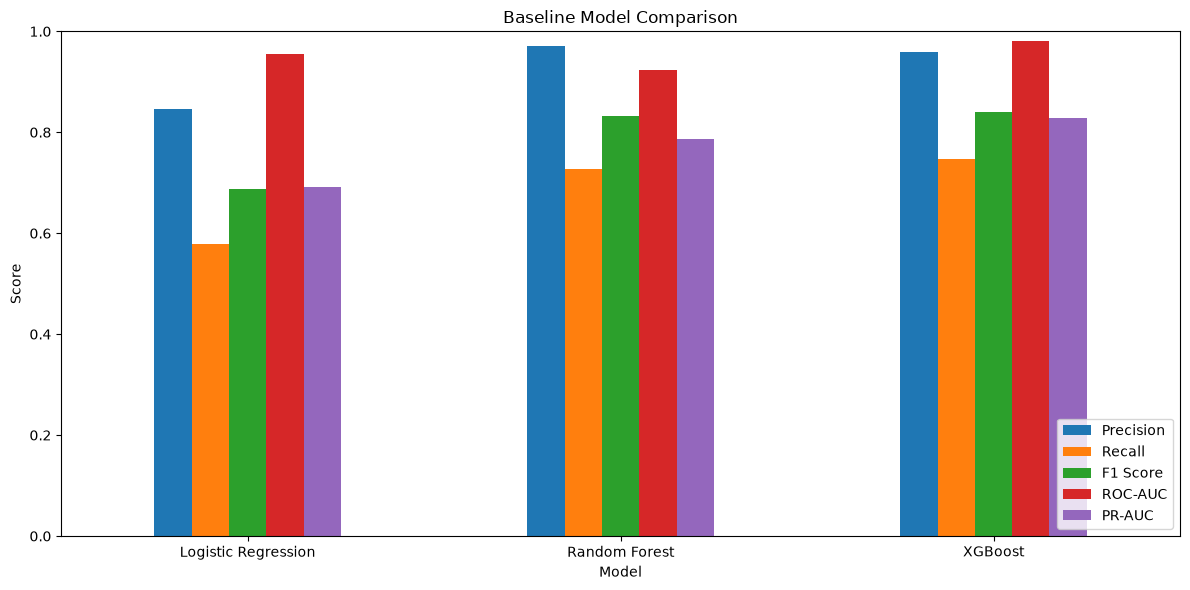

In [10]:
# Compare important metrics
metrics = ["Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"]

results.set_index("Model")[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Baseline Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.legend(loc="lower right")

plt.tight_layout()
plt.show()

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix
)

# Train logistic regression with class weights
weighted_logistic = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

weighted_logistic.fit(X_train_scaled, y_train)

weighted_lr_pred = weighted_logistic.predict(X_test_scaled)
weighted_lr_prob = weighted_logistic.predict_proba(X_test_scaled)[:, 1]


# Train random forest with class weights
weighted_rf = RandomForestClassifier(
    n_estimators=150,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

weighted_rf.fit(X_train, y_train)

weighted_rf_pred = weighted_rf.predict(X_test)
weighted_rf_prob = weighted_rf.predict_proba(X_test)[:, 1]


# Calculate the fraud weight for XGBoost
fraud_count = (y_train == 1).sum()
legitimate_count = (y_train == 0).sum()

scale_pos_weight = legitimate_count / fraud_count

print("XGBoost scale_pos_weight:", round(scale_pos_weight, 2))


# Train XGBoost with class weighting
weighted_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

weighted_xgb.fit(X_train, y_train)

weighted_xgb_pred = weighted_xgb.predict(X_test)
weighted_xgb_prob = weighted_xgb.predict_proba(X_test)[:, 1]


# Create a function to calculate model metrics
def calculate_metrics(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob)
    }


# Calculate metrics
weighted_results = pd.DataFrame({
    "Logistic Regression": calculate_metrics(
        y_test,
        weighted_lr_pred,
        weighted_lr_prob
    ),
    "Random Forest": calculate_metrics(
        y_test,
        weighted_rf_pred,
        weighted_rf_prob
    ),
    "XGBoost": calculate_metrics(
        y_test,
        weighted_xgb_pred,
        weighted_xgb_prob
    )
}).T


# Round the results
weighted_results = weighted_results.round(4)

print("\nClass-weighted model results:")
display(weighted_results)

XGBoost scale_pos_weight: 599.48

Class-weighted model results:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
Logistic Regression,0.9753,0.0564,0.8737,0.1059,0.9657,0.6719
Random Forest,0.9995,0.9583,0.7263,0.8263,0.9484,0.8008
XGBoost,0.9995,0.9367,0.7789,0.8506,0.9761,0.8248


In [12]:
# Combine baseline and weighted model results
comparison = pd.concat([
    results.set_index("Model"),
    weighted_results
])

# Sort by PR-AUC
comparison = comparison.sort_values(
    by="PR-AUC",
    ascending=False
)

# Display comparison
display(comparison.round(4))

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
XGBoost,0.9995,0.9595,0.7474,0.8402,0.9803,0.8290
XGBoost,0.9995,0.9367,0.7789,0.8506,0.9761,0.8248
Random Forest,0.9995,0.9583,0.7263,0.8263,0.9484,0.8008
Random Forest,0.9995,0.9718,0.7263,0.8313,0.9239,0.7876
Logistic Regression,0.9991,0.8462,0.5789,0.6875,0.9560,0.6920
Logistic Regression,0.9753,0.0564,0.8737,0.1059,0.9657,0.6719


In [13]:
from imblearn.over_sampling import SMOTE

# Create the SMOTE sampler
smote = SMOTE(
    sampling_strategy=0.5,
    random_state=42,
    k_neighbors=5
)

# Generate synthetic fraud samples
X_train_smote, y_train_smote = smote.fit_resample(
    X_train,
    y_train
)

# Check the new class distribution
print("Original training distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

# Show the new class percentages
print("\nAfter SMOTE percentages:")
print(
    (y_train_smote.value_counts(normalize=True) * 100)
    .sort_index()
)

Original training distribution:
Class
0    226602
1       378
Name: count, dtype: int64

After SMOTE:
Class
0    226602
1    113301
Name: count, dtype: int64

After SMOTE percentages:
Class
0    66.666667
1    33.333333
Name: proportion, dtype: float64


In [14]:
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    classification_report,
    confusion_matrix
)

# Create the SMOTE XGBoost model
smote_xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

# Train using the SMOTE training data
smote_xgb.fit(
    X_train_smote,
    y_train_smote
)

# Predict on the original test data
smote_pred = smote_xgb.predict(X_test)

# Get fraud probabilities
smote_prob = smote_xgb.predict_proba(X_test)[:, 1]

# Calculate metrics
smote_accuracy = accuracy_score(y_test, smote_pred)
smote_precision = precision_score(
    y_test,
    smote_pred,
    zero_division=0
)
smote_recall = recall_score(
    y_test,
    smote_pred,
    zero_division=0
)
smote_f1 = f1_score(
    y_test,
    smote_pred,
    zero_division=0
)
smote_roc_auc = roc_auc_score(
    y_test,
    smote_prob
)
smote_pr_auc = average_precision_score(
    y_test,
    smote_prob
)

# Display results
print("=" * 50)
print("SMOTE + XGBOOST RESULTS")
print("=" * 50)

print(f"Accuracy  : {smote_accuracy:.4f}")
print(f"Precision : {smote_precision:.4f}")
print(f"Recall    : {smote_recall:.4f}")
print(f"F1 Score  : {smote_f1:.4f}")
print(f"ROC-AUC   : {smote_roc_auc:.4f}")
print(f"PR-AUC    : {smote_pr_auc:.4f}")

# Show classification report
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        smote_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

# Show confusion matrix
smote_cm = confusion_matrix(
    y_test,
    smote_pred
)

print("\nConfusion Matrix:")
print(smote_cm)

SMOTE + XGBOOST RESULTS
Accuracy  : 0.9994
Precision : 0.8539
Recall    : 0.8000
F1 Score  : 0.8261
ROC-AUC   : 0.9656
PR-AUC    : 0.8212

Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.85      0.80      0.83        95

    accuracy                           1.00     56746
   macro avg       0.93      0.90      0.91     56746
weighted avg       1.00      1.00      1.00     56746


Confusion Matrix:
[[56638    13]
 [   19    76]]


In [15]:
# Add the SMOTE model to our comparison
comparison.loc["SMOTE + XGBoost"] = [
    smote_accuracy,
    smote_precision,
    smote_recall,
    smote_f1,
    smote_roc_auc,
    smote_pr_auc
]

# Sort models by PR-AUC
comparison = comparison.sort_values(
    by="PR-AUC",
    ascending=False
)

display(comparison.round(4))

,Accuracy,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
XGBoost,0.9995,0.9595,0.7474,0.8402,0.9803,0.8290
XGBoost,0.9995,0.9367,0.7789,0.8506,0.9761,0.8248
SMOTE + XGBoost,0.9994,0.8539,0.8000,0.8261,0.9656,0.8212
Random Forest,0.9995,0.9583,0.7263,0.8263,0.9484,0.8008
Random Forest,0.9995,0.9718,0.7263,0.8313,0.9239,0.7876
Logistic Regression,0.9991,0.8462,0.5789,0.6875,0.9560,0.6920
Logistic Regression,0.9753,0.0564,0.8737,0.1059,0.9657,0.6719


In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

# Store the test probabilities
probabilities = smote_prob

# Try different probability thresholds
thresholds = np.arange(0.10, 0.91, 0.05)

threshold_results = []

for threshold in thresholds:

    # Convert probabilities into predictions
    predictions = (probabilities >= threshold).astype(int)

    # Calculate metrics
    precision_value = precision_score(
        y_test,
        predictions,
        zero_division=0
    )

    recall_value = recall_score(
        y_test,
        predictions,
        zero_division=0
    )

    f1_value = f1_score(
        y_test,
        predictions,
        zero_division=0
    )

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_value,
        "Recall": recall_value,
        "F1 Score": f1_value
    })

# Create a results table
threshold_df = pd.DataFrame(threshold_results)

# Display the results
display(threshold_df.round(4))

,Threshold,Precision,Recall,F1 Score
0,0.10,0.5417,0.8211,0.6527
1,0.15,0.6080,0.8000,0.6909
2,0.20,0.6909,0.8000,0.7415
3,0.25,0.7379,0.8000,0.7677
4,0.30,0.7677,0.8000,0.7835
5,0.35,0.7835,0.8000,0.7917
6,0.40,0.7917,0.8000,0.7958
7,0.45,0.8085,0.8000,0.8042
8,0.50,0.8539,0.8000,0.8261
9,0.55,0.8636,0.8000,0.8306


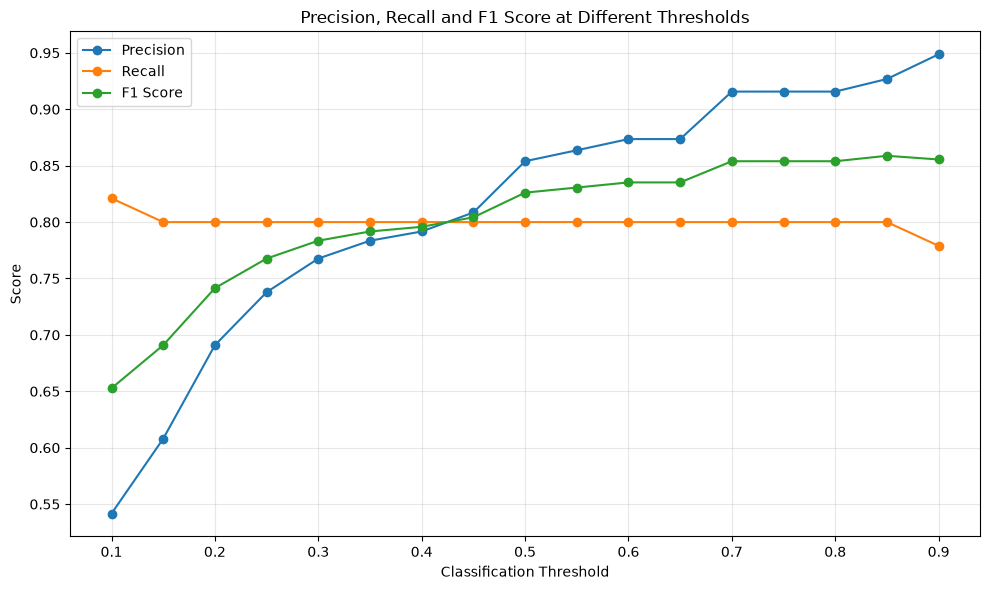

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1 Score at Different Thresholds")

plt.grid(alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [18]:
best_threshold_row = threshold_df.loc[
    threshold_df["F1 Score"].idxmax()
]

best_threshold = best_threshold_row["Threshold"]

print("Best threshold based on F1 Score:")
print(f"{best_threshold:.2f}")

print("\nMetrics at the selected threshold:")
print(
    best_threshold_row[
        ["Precision", "Recall", "F1 Score"]
    ].round(4)
)

Best threshold based on F1 Score:
0.85

Metrics at the selected threshold:
Precision    0.9268
Recall       0.8000
F1 Score     0.8588
Name: 15, dtype: float64


Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00     56651
       Fraud       0.93      0.80      0.86        95

    accuracy                           1.00     56746
   macro avg       0.96      0.90      0.93     56746
weighted avg       1.00      1.00      1.00     56746

ROC-AUC: 0.9656
PR-AUC:  0.8212

Confusion Matrix:
[[56645     6]
 [   19    76]]


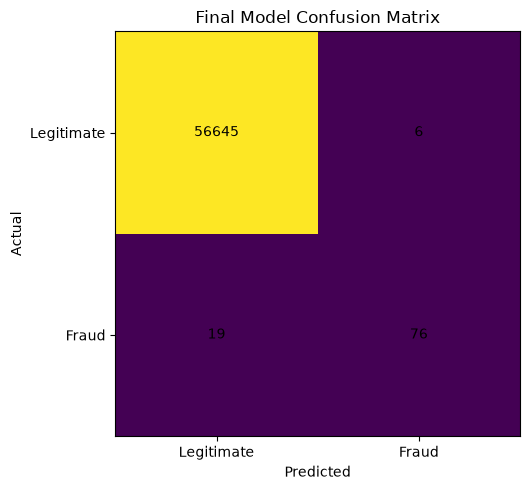

In [19]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score
)
import matplotlib.pyplot as plt

# Use the SMOTE + XGBoost probabilities
final_prob = smote_prob

# Apply the selected threshold
final_pred = (final_prob >= best_threshold).astype(int)

# Print classification report
print("Classification Report:")
print(
    classification_report(
        y_test,
        final_pred,
        target_names=["Legitimate", "Fraud"],
        zero_division=0
    )
)

# Calculate final metrics
final_roc_auc = roc_auc_score(y_test, final_prob)
final_pr_auc = average_precision_score(y_test, final_prob)

print(f"ROC-AUC: {final_roc_auc:.4f}")
print(f"PR-AUC:  {final_pr_auc:.4f}")

# Confusion matrix
final_cm = confusion_matrix(y_test, final_pred)

print("\nConfusion Matrix:")
print(final_cm)

# Display confusion matrix
plt.figure(figsize=(6, 5))

plt.imshow(final_cm)

plt.title("Final Model Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.xticks([0, 1], ["Legitimate", "Fraud"])
plt.yticks([0, 1], ["Legitimate", "Fraud"])

for i in range(2):
    for j in range(2):
        plt.text(j, i, final_cm[i, j], ha="center", va="center")

plt.tight_layout()
plt.show()

d:\Fraud Detection system\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


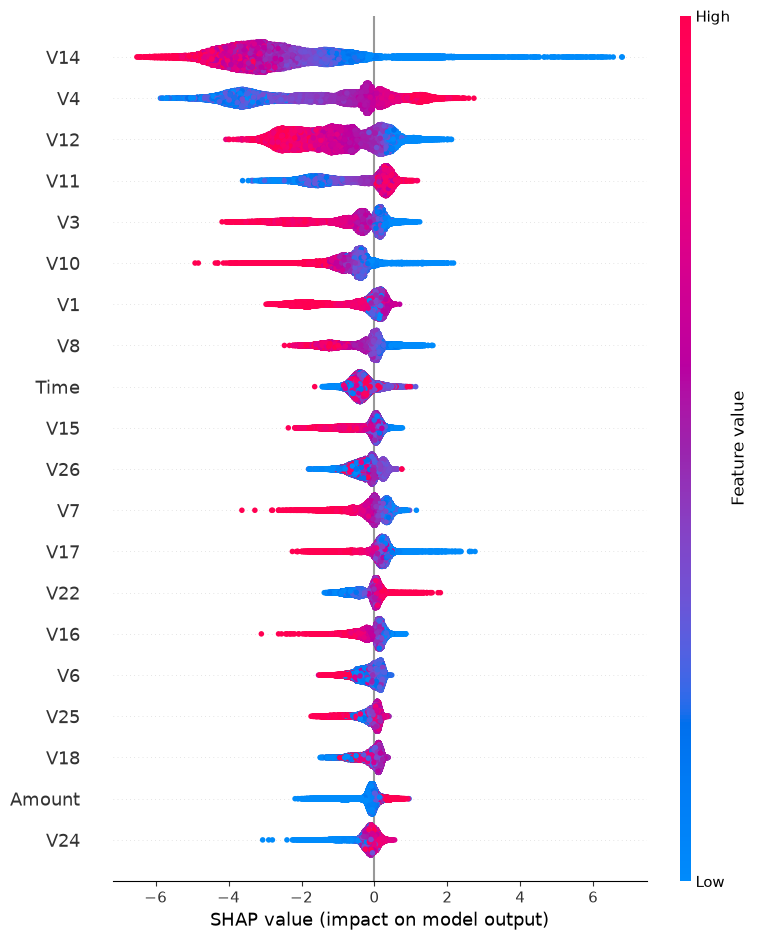

In [21]:
import shap
import matplotlib.pyplot as plt

# Create SHAP explainer
explainer = shap.TreeExplainer(smote_xgb)

# Calculate SHAP values on test data
shap_values = explainer.shap_values(X_test)

# Show feature importance
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns
)

In [22]:
import joblib
import os

# Create model folder
os.makedirs("../models", exist_ok=True)

# Save the trained model
joblib.dump(smote_xgb, "../models/fraud_xgb_model.pkl")

# Save the scaler
joblib.dump(scaler, "../models/scaler.pkl")

# Save the selected threshold
joblib.dump(best_threshold, "../models/threshold.pkl")

print("Model saved successfully.")
print(f"Threshold saved: {best_threshold:.2f}")

Model saved successfully.
Threshold saved: 0.85


In [23]:
import numpy as np
import pandas as pd
import joblib

# Load saved model files
model = joblib.load("../models/fraud_xgb_model.pkl")
scaler = joblib.load("../models/scaler.pkl")
threshold = joblib.load("../models/threshold.pkl")

def predict_fraud(transaction):
    
    # Convert input into DataFrame
    transaction_df = pd.DataFrame([transaction])

    # Scale the transaction
    transaction_scaled = scaler.transform(transaction_df)

    # Get fraud probability
    fraud_probability = model.predict_proba(transaction_scaled)[0][1]

    # Apply selected threshold
    prediction = int(fraud_probability >= threshold)

    if prediction == 1:
        result = "Fraud"
    else:
        result = "Legitimate"

    return {
        "prediction": result,
        "fraud_probability": round(fraud_probability, 4),
        "threshold": round(threshold, 4)
    }

print("Prediction function created successfully.")

Prediction function created successfully.


In [24]:
# Take one transaction from the test set
sample_transaction = X_test.iloc[0].to_dict()

# Make prediction
result = predict_fraud(sample_transaction)

print(result)

{'prediction': 'Legitimate', 'fraud_probability': np.float32(0.0), 'threshold': np.float64(0.85)}
